In [254]:
import matplotlib.pyplot as plt

from utils import read_ooc, read_xrr
from utils.helpers.plotting_helper import set_plotting_defaults

set_plotting_defaults()
ooc = read_ooc("dft.csv", material="znpc")


## 0. Load data and fits

Experimental XRMR curves plus the free-tensor and DFT-slab ``GlobalObjective``
pickles used for Fig. 2 and the SI geometry tables.


In [255]:
loaded_data = read_xrr("reflectivity_data", material="znpc")


In [256]:
ens = [float(k) for k in loaded_data.keys()]
ens.sort()

In [257]:
import pickle

from utils import models_root

with open(models_root / "xrr/znpc/dft/dft_en_offset_new2.pkl", "rb") as f:
    dft_constrained = pickle.load(f)
with open(models_root / "xrr/znpc/free/free_en_offset_init_2.pkl", "rb") as f:
    exp_constrained = pickle.load(f)

# Figure 2 — fit comparison

Load free-tensor and DFT-slab fits, render the full-width reflectivity
comparison (Diagnostic | Pre-edge | Resonant), SI geometry tables, fit-quality
metrics, and the optical-constants vs orientation auxiliary panel.


## 1. Fit-comparison figure helpers


In [258]:
"""
Main-text fit-result figure helpers for Fig. 2.

Public entry point
    plot_fit_comparison_full_width — Diagnostic | Pre-edge | Resonant row.

Critical-angle markers are drawn only on the pre-edge waterfall (DFT-model Q_c).
"""

from __future__ import annotations

from collections.abc import Sequence
from pathlib import Path

import matplotlib.gridspec as gs
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import patheffects as pe
from matplotlib.lines import Line2D
from matplotlib.ticker import MultipleLocator

_HC_EV_ANG = 12398.4198
FIG_W_FULL = 7.5
_LABEL_HALO = [pe.withStroke(linewidth=1.6, foreground="white")]
_QC_S_MARKER = dict(marker="v", markerfacecolor="k", markeredgecolor="k")
_QC_P_MARKER = dict(marker="o", markerfacecolor="none", markeredgecolor="k")
_QC_HALO = [pe.withStroke(linewidth=2.2, foreground="white")]


def rxr(x, model, pol):
    """Evaluate ``model`` at ``x`` for polarization ``pol``, restoring prior pol."""
    _pol = model.pol
    model.pol = pol
    try:
        y = model(x)
    finally:
        model.pol = _pol
    return y


def _q_critical(objective, pol: str = "s") -> float | None:
    """
    Q at the critical angle for a single objective and polarization.

    s uses in-plane decrement ``delta_xx``; p uses out-of-plane ``delta_zz``,
    both from structure layer index 2. Returns ``None`` when absent or
    non-physical (``delta <= 0``).
    """
    try:
        energy = float(objective.model.energy)
        if pol == "s":
            d = float(objective.model.structure[2].sld.tensor[0, 0].real)
        elif pol == "p":
            d = float(objective.model.structure[2].sld.tensor[2, 2].real)
        else:
            raise ValueError(f"Unknown pol: {pol!r}")
    except (AttributeError, IndexError, TypeError):
        return None
    if not np.isfinite(d) or d <= 0:
        return None
    lam_ang = _HC_EV_ANG / energy
    theta_c = float(np.sqrt(2.0 * d))
    return float(4.0 * np.pi * np.sin(theta_c) / lam_ang)


def _format_energy_tick_label(energy: float) -> str:
    rounded = round(energy)
    if np.isclose(energy, rounded, rtol=0.0, atol=1e-6):
        return f"{int(rounded)}"
    text = f"{energy:.1f}"
    if "." in text:
        text = text.rstrip("0").rstrip(".")
    return text


def _annotate_above_curve(
    ax, q_anchor, y_anchor, text, *, color, fontsize=7, offset_pts=5,
    weight="normal",
):
    ann = ax.annotate(
        text,
        (float(q_anchor), float(y_anchor)),
        xytext=(0, offset_pts),
        textcoords="offset points",
        ha="center",
        va="bottom",
        color=color,
        fontsize=fontsize,
        fontweight=weight,
    )
    ann.set_path_effects(_LABEL_HALO)
    return ann


def _resolve_per_energy_q(
    value: float | Sequence[float],
    n_energies: int,
    name: str,
) -> list[float]:
    if np.isscalar(value):
        return [float(value)] * n_energies
    arr = list(value)
    if len(arr) != n_energies:
        raise ValueError(
            f"{name} has length {len(arr)} but reference_energies has "
            f"length {n_energies}."
        )
    return [float(v) for v in arr]


def _subsample_reflectivity(
    x,
    y,
    yerr,
    every: int,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Return aligned ``(x, y, yerr)`` slices for every-nth reflectivity sample.

    Matplotlib ``errorbar(..., markevery=n)`` still draws caps on every point;
    explicit slicing keeps markers and error bars on the same indices.
    """
    x_arr = np.asarray(x, dtype=np.float64)
    y_arr = np.asarray(y, dtype=np.float64)
    err_arr = np.asarray(yerr, dtype=np.float64)
    if every <= 1:
        return x_arr, y_arr, err_arr
    idx = np.arange(0, len(x_arr), every, dtype=int)
    return x_arr[idx], y_arr[idx], err_arr[idx]


def _plot_reflectivity_points(
    ax,
    x,
    y,
    yerr,
    *,
    color,
    marker: str,
    every: int = 1,
    show_yerr: bool = False,
    markersize: float = 3.0,
    markeredgewidth: float = 0.6,
    alpha: float = 1.0,
    zorder: float = 10,
) -> None:
    """
    Draw reflectivity markers with optional capped error bars.

    ``every`` keeps only every-nth sample in ``x``, ``y``, and ``yerr`` before
    plotting so markers and error bars share identical coordinates.
    """
    x_arr, y_arr, err_arr = _subsample_reflectivity(x, y, yerr, every)
    if x_arr.size == 0:
        return
    capsize = max(1.2, 0.55 * markersize)
    err_lw = 0.45
    if show_yerr:
        ax.errorbar(
            x_arr,
            y_arr,
            yerr=err_arr,
            fmt=marker,
            lw=0,
            color=color,
            ecolor=color,
            capsize=capsize,
            capthick=err_lw,
            elinewidth=err_lw,
            markersize=markersize,
            markerfacecolor=color,
            markeredgecolor=color,
            markeredgewidth=markeredgewidth,
            alpha=alpha,
            zorder=zorder,
        )
        return
    ax.plot(
        x_arr,
        y_arr,
        linestyle="None",
        marker=marker,
        color=color,
        markersize=markersize,
        markerfacecolor=color,
        markeredgewidth=markeredgewidth,
        alpha=alpha,
        zorder=zorder,
    )


def _waterfall_qc_point(
    pol: str,
    *,
    o_dft,
    pol_data,
    offset: float,
    q_xlim: tuple[float, float],
) -> tuple[float, float] | None:
    """
    Place one Q_c marker at measured ``R(Q_c)`` on the offset waterfall row.

    Q comes from the DFT tensor edge; the vertical position follows the data
    so markers sit on the experimental fall rather than on the model plateau.
    """
    q_c = _q_critical(o_dft, pol=pol)
    if q_c is None or not (q_xlim[0] <= q_c <= q_xlim[1]):
        return None
    q = np.asarray(pol_data.x, dtype=np.float64)
    r = np.asarray(pol_data.y, dtype=np.float64)
    if q.size < 2:
        return None
    y_data = float(np.interp(q_c, q, r, left=np.nan, right=np.nan))
    if not np.isfinite(y_data) or y_data <= 0:
        return None
    return float(q_c), y_data * offset


def _plot_vertically_offset_energies(
    ax, energies, exp_objectives, dft_objectives, loaded_data,
    *,
    offset_scale: float = -1.5,
    q_xlim: tuple[float, float] = (0.002, 0.07),
    show_qc_s: bool = False,
    show_qc_p: bool = False,
    qc_markersize: float = 2.4,
    qc_s_connect: str | None = None,
    qc_p_connect: str | None = None,
    qc_connect_linewidth: float = 0.6,
    plot_energy_labels: bool = False,
    energy_label_pad_frac: float = 0.04,
    ylim_bottom_factor: float = 1.0,
    highlight_q: float | None = None,
    smarker: str = "o",
    pmarker: str = "^",
    every: int = 3,
    markersize: float = 2.8,
    model_lw: float = 0.55,
    show_yerr: bool = True,
):
    """
    Vertically-offset waterfall of s/p reflectivity for each energy.

    Optional DFT Q_c markers (connected across energies) sit on the measured
    curve at each Q_c. ``highlight_q`` draws a faint vertical guide (e.g. 0.04).
    """
    cmap = plt.colormaps.get_cmap("tab20")
    xdata = np.linspace(0.0005, 0.27, 1000)

    last_y_min = 1e-12
    qc_pts: dict[str, list[tuple[float, float]]] = {"s": [], "p": []}
    point_batches: list[tuple] = []

    for idx, energy in enumerate(energies):
        if energy not in exp_objectives:
            continue
        o_exp = exp_objectives[energy]
        o_dft = dft_objectives[energy]
        data = loaded_data[str(energy)]
        offset = 10 ** (offset_scale * idx)

        if plot_energy_labels:
            pad = energy_label_pad_frac * (q_xlim[1] - q_xlim[0])
            q_anchor = q_xlim[1] - pad
            y_e = float(rxr(np.array([q_anchor]), o_exp.model, "s")[0]) * offset
            ann = ax.annotate(
                f"{_format_energy_tick_label(float(energy))} eV",
                xy=(q_anchor, y_e),
                xytext=(0, 3),
                textcoords="offset points",
                ha="right",
                va="bottom",
                color=cmap(2 * idx % 20),
                fontsize=6.5,
                fontweight="bold",
                zorder=11,
            )
            ann.set_path_effects(_LABEL_HALO)

        for pol, m in (("s", smarker), ("p", pmarker)):
            pol_data = getattr(data, pol)
            color = (
                cmap(2 * idx % 20) if pol == "s" else cmap((2 * idx + 1) % 20)
            )
            point_batches.append(
                (
                    pol_data.x,
                    pol_data.y * offset,
                    pol_data.y_err * offset,
                    color,
                    m,
                )
            )
        for pol in ("s", "p"):
            y_exp = rxr(xdata, o_exp.model, pol)
            y_dft = rxr(xdata, o_dft.model, pol)
            ax.plot(
                xdata, y_exp * offset, color="k", lw=model_lw, ls="-", zorder=1,
            )
            ax.plot(
                xdata, y_dft * offset, color="k", lw=model_lw, ls="--", zorder=1,
            )
        last_y_min = offset * pol_data.y.min()
        smark = _QC_S_MARKER | {"marker": smarker}
        pmark = _QC_P_MARKER | {"marker": pmarker}
        for pol, show, style in (
            ("s", show_qc_s, smark),
            ("p", show_qc_p, pmark),
        ):
            if not show:
                continue
            pol_data = getattr(data, pol)
            pt = _waterfall_qc_point(
                pol,
                o_dft=o_dft,
                pol_data=pol_data,
                offset=offset,
                q_xlim=q_xlim,
            )
            if pt is None:
                continue
            q_c, y_qc = pt
            qc_pts[pol].append((q_c, y_qc))
            line, = ax.plot(
                [q_c], [y_qc], linestyle="None",
                markersize=qc_markersize, markeredgewidth=0.65,
                zorder=12, **style,
            )
            line.set_path_effects(_QC_HALO)

    for pol, connect in (("s", qc_s_connect), ("p", qc_p_connect)):
        if connect is None or len(qc_pts[pol]) < 2:
            continue
        xs, ys = zip(*qc_pts[pol])
        conn, = ax.plot(
            xs, ys, linestyle=connect, linewidth=qc_connect_linewidth,
            color="0.25", marker="None", zorder=11,
        )
        conn.set_path_effects(_QC_HALO)

    ax.set_yscale("log")
    ax.set_xlim(*q_xlim)
    bottom = last_y_min * ylim_bottom_factor
    if bottom <= 0:
        bottom = last_y_min * 0.5
    ax.set_ylim(bottom, 1)
    for x_pts, y_pts, yerr_pts, color, m in point_batches:
        _plot_reflectivity_points(
            ax,
            x_pts,
            y_pts,
            yerr_pts,
            color=color,
            marker=m,
            every=every,
            show_yerr=show_yerr,
            markersize=markersize,
            zorder=10,
        )
    if highlight_q is not None:
        ax.axvline(
            highlight_q, color="0.35", lw=0.6, ls=":", alpha=0.85, zorder=0,
        )
    ax.set_xticks([0.02, 0.04, 0.06])
    ax.set_xticklabels([r"$0.02$", r"$0.04$", r"$0.06$"])
    ax.xaxis.set_minor_locator(MultipleLocator(0.01))
    ax.minorticks_on()
    ax.grid(True, which="major", alpha=0.3)


def _plot_reference_pair(
    ax,
    comparison_energies,
    exp_objectives,
    dft_objectives,
    loaded_data,
    *,
    energy_label_q,
    label_offset_pts: float = 5.0,
    show_energy_labels: bool = True,
    s_swatch: str = "0.20",
    p_swatch: str = "0.65",
    smarker="o",
    pmarker="^",
    every: int = 3,
    markersize: float = 2.8,
    model_lw: float = 0.55,
    show_yerr: bool = True,
):
    """
    Diagnostic panel: full-Q data and model traces for reference energies.

    Point styling matches the pre-edge and resonant waterfall panels.
    """
    cmap = plt.colormaps.get_cmap("tab20")
    last_y_min = 1e-12
    point_batches: list[tuple] = []

    q_anchors = _resolve_per_energy_q(
        energy_label_q, len(comparison_energies), "energy_label_q",
    )

    for i, energy in enumerate(comparison_energies):
        o_exp = exp_objectives[energy]
        o_dft = dft_objectives[energy]
        data = loaded_data[str(energy)]
        scale = 10 ** (-3 * i)
        energy_col = cmap(2 * i)

        for pol, m in (("s", smarker), ("p", pmarker)):
            col = cmap(2 * i) if pol == "s" else cmap(2 * i + 1)
            pol_data = getattr(data, pol)
            point_batches.append(
                (
                    pol_data.x,
                    pol_data.y * scale,
                    pol_data.y_err * scale,
                    col,
                    m,
                )
            )
        for pol in ("s", "p"):
            pol_data = getattr(data, pol)
            y_exp = rxr(pol_data.x, o_exp.model, pol)
            y_dft = rxr(pol_data.x, o_dft.model, pol)
            ax.plot(
                pol_data.x, y_exp * scale, color="k", lw=model_lw, ls="-", zorder=1,
            )
            ax.plot(
                pol_data.x, y_dft * scale, color="k", lw=model_lw, ls="--", zorder=1,
            )
        last_y_min = scale * pol_data.y.min()

        if show_energy_labels:
            q_anchor = q_anchors[i]
            y_e = float(rxr(np.array([q_anchor]), o_exp.model, "s")[0]) * scale
            _annotate_above_curve(
                ax, q_anchor, y_e,
                f"{_format_energy_tick_label(float(energy))} eV",
                color=energy_col,
                fontsize=7,
                offset_pts=label_offset_pts,
                weight="bold",
            )

    ax.set_xlim(0.002, 0.27)
    ax.set_yscale("log")
    ax.set_yticklabels([])
    ax.set_xticks([0.0, 0.05, 0.10, 0.15, 0.20, 0.25])
    ax.set_xticklabels(
        [r"$0$", r"$0.05$", r"$0.10$", r"$0.15$", r"$0.20$", r"$0.25$"]
    )
    ax.xaxis.set_minor_locator(MultipleLocator(0.01))
    ax.minorticks_on()
    ax.grid(True, which="major", alpha=0.3)
    ax.set_ylim(last_y_min, 1)

    for x_pts, y_pts, yerr_pts, color, m in point_batches:
        _plot_reflectivity_points(
            ax,
            x_pts,
            y_pts,
            yerr_pts,
            color=color,
            marker=m,
            every=every,
            show_yerr=show_yerr,
            markersize=markersize,
            zorder=10,
        )

    handles = [
        Line2D([], [], color="k", lw=1.1, ls="-", label="Free Slab"),
        Line2D([], [], color="k", lw=1.1, ls="--", label="DFT Slab"),
        Line2D(
            [], [], color=s_swatch, marker=smarker, markersize=5,
            markerfacecolor=s_swatch, markeredgecolor=s_swatch,
            linestyle="None", label=r"$s$",
        ),
        Line2D(
            [], [], color=p_swatch, marker=pmarker, markersize=5,
            markerfacecolor=p_swatch, markeredgecolor=p_swatch,
            linestyle="None", label=r"$p$",
        ),
    ]
    ax.legend(
        handles=handles, loc="lower left", fontsize=6.5, ncols=2,
        handlelength=1.2, columnspacing=0.8, handletextpad=0.4,
        borderpad=0.3, labelspacing=0.25,
        framealpha=0.9, edgecolor="0.75", fancybox=False,
    )


def plot_fit_comparison_full_width(
    exp_constrained,
    dft_constrained,
    loaded_data,
    save_path: Path | str | None = None,
    *,
    smarker="o",
    pmarker="^",
    reference_energies: Sequence[float] = (250.0, 283.7),
    energy_label_q: float | Sequence[float] = (0.07, 0.025),
    label_offset_pts: float = 5.0,
    show_energy_labels: bool = False,
    legend_s_swatch: str = "0.20",
    legend_p_swatch: str = "0.65",
    show_qc_preedge: bool = True,
    qc_waterfall_markersize: float = 2.4,
    qc_s_connect: str | None = "-",
    qc_p_connect: str | None = "-",
    qc_connect_linewidth: float = 0.6,
    energy_labels_resonant: bool = False,
    energy_label_pad_frac: float = 0.04,
    waterfall_every: int = 3,
    waterfall_markersize: float = 2.8,
    waterfall_show_yerr: bool = True,
    resonant_offset_scale: float = -3.0,
    resonant_ylim_bottom: float = 0.035,
    resonant_highlight_q: float = 0.04,
):
    """
    Full text-width row: Diagnostic | Pre-edge | Resonant.

    Panel (c) uses the same subsampled markers, capped error bars, and model
    line weights as panels (d) and (e).
    """
    exp_objectives = {obj.model.energy: obj for obj in exp_constrained.objectives}
    dft_objectives = {obj.model.energy: obj for obj in dft_constrained.objectives}
    common_energies = sorted(set(exp_objectives) & set(dft_objectives))
    if not common_energies:
        raise ValueError("exp_constrained and dft_constrained share no energies.")

    fig = plt.figure(figsize=(FIG_W_FULL, 3.0), dpi=600)
    outer = gs.GridSpec(
        1, 3, figure=fig, width_ratios=[1.5, 1.0, 1.0], wspace=0.1,
        left=0.07, right=0.99, top=0.94, bottom=0.20,
    )
    ax_c = fig.add_subplot(outer[0])
    ax_d = fig.add_subplot(outer[1])
    ax_e = fig.add_subplot(outer[2])

    for ax in (ax_c, ax_d, ax_e):
        ax.tick_params(axis="both", labelsize=8)
        ax.xaxis.label.set_size(9)
        ax.yaxis.label.set_size(9)

    _plot_reference_pair(
        ax_c, np.asarray(reference_energies, dtype=np.float64),
        exp_objectives, dft_objectives, loaded_data,
        energy_label_q=energy_label_q,
        label_offset_pts=label_offset_pts,
        show_energy_labels=show_energy_labels,
        s_swatch=legend_s_swatch,
        p_swatch=legend_p_swatch,
        smarker=smarker,
        pmarker=pmarker,
        every=waterfall_every,
        markersize=waterfall_markersize,
        show_yerr=waterfall_show_yerr,
    )

    non_resonant = [e for e in common_energies if 250.0 < e < 283.7]
    resonant = [e for e in common_energies if e > 283.7]
    _plot_vertically_offset_energies(
        ax_d, non_resonant, exp_objectives, dft_objectives, loaded_data,
        offset_scale=-0.5,
        show_qc_s=show_qc_preedge,
        show_qc_p=show_qc_preedge,
        qc_markersize=qc_waterfall_markersize,
        qc_s_connect=qc_s_connect if show_qc_preedge else None,
        qc_p_connect=qc_p_connect if show_qc_preedge else None,
        qc_connect_linewidth=qc_connect_linewidth,
        plot_energy_labels=False,
        energy_label_pad_frac=energy_label_pad_frac,
        every=waterfall_every,
        markersize=waterfall_markersize,
        show_yerr=waterfall_show_yerr,
    )
    _plot_vertically_offset_energies(
        ax_e, resonant, exp_objectives, dft_objectives, loaded_data,
        offset_scale=resonant_offset_scale,
        ylim_bottom_factor=resonant_ylim_bottom,
        show_qc_s=False,
        show_qc_p=False,
        plot_energy_labels=energy_labels_resonant,
        energy_label_pad_frac=energy_label_pad_frac,
        every=waterfall_every,
        highlight_q=resonant_highlight_q,
        model_lw=0.65,
        markersize=3.0,
        show_yerr=waterfall_show_yerr,
    )
    for ax in (ax_d, ax_e):
        ax.set_ylabel("")
        ax.set_yticklabels([])

    q_xlabel = r"$Q$ ($\mathrm{\AA}^{-1}$)"
    ax_c.set_ylabel(r"Reflectivity (a.u.)", fontsize=9)
    for ax in (ax_c, ax_d, ax_e):
        ax.set_xlabel(q_xlabel, fontsize=9)

    for ax, lbl in zip([ax_c, ax_d, ax_e], ("(c)", "(d)", "(e)")):
        ax.text(
            -0.1, 0.95, lbl,
            transform=ax.transAxes, va="bottom", ha="left", fontsize=9,
            clip_on=False,
        )
    fig.align_labels()

    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, dpi=300, bbox_inches="tight", transparent=True)
    else:
        plt.show()
    return fig


## 2. Full-width figure


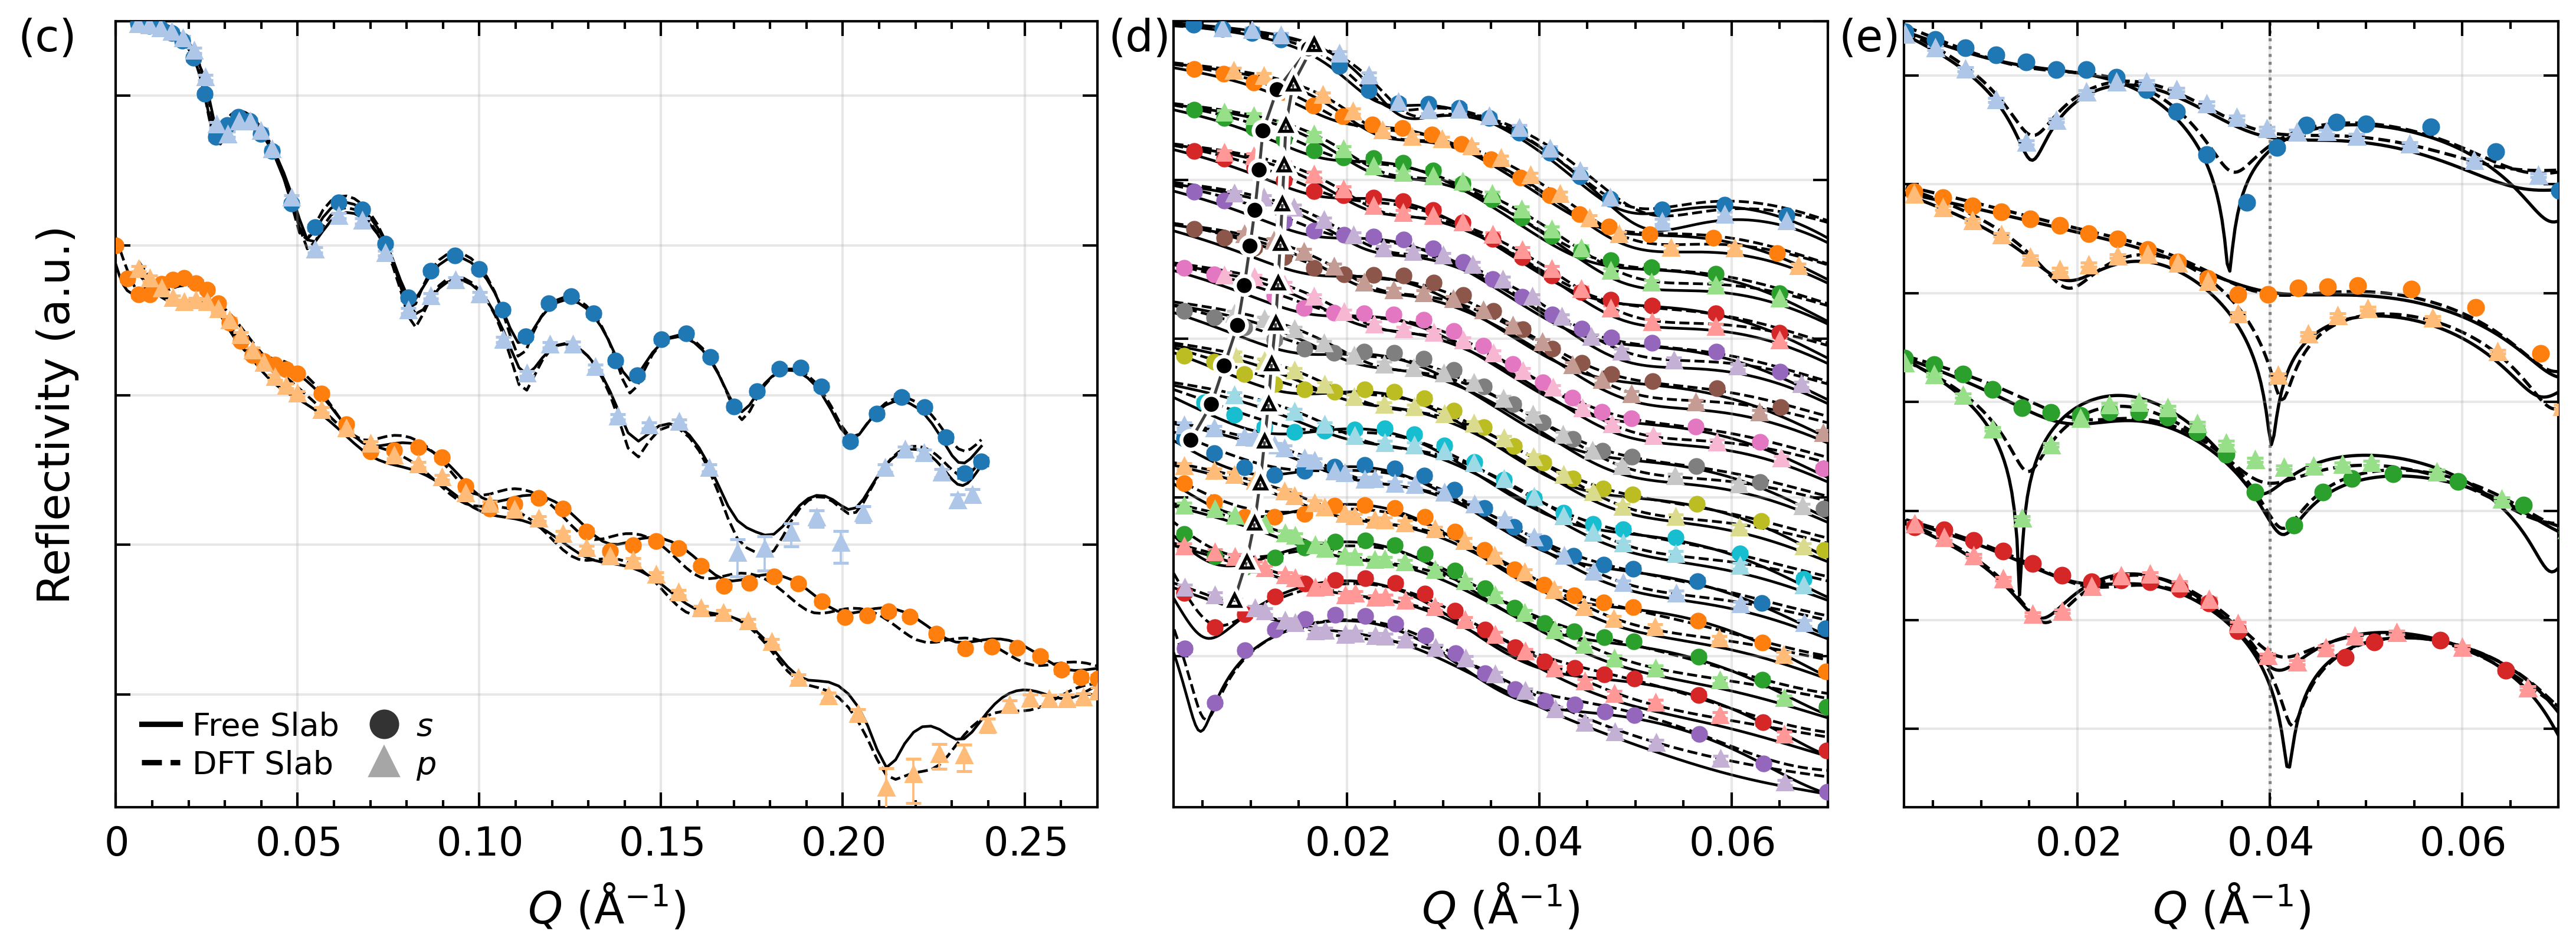

In [259]:
_common_kwargs = {
    "show_energy_labels": False,
    "energy_labels_resonant": False,
    "show_qc_preedge": True,
    "qc_s_connect": "-",
    "qc_p_connect": "-",
    "qc_connect_linewidth": 0.6,
    "qc_waterfall_markersize": 2.4,
    "waterfall_every": 3,
    "waterfall_show_yerr": True,
    "waterfall_markersize": 2.8,
    "resonant_highlight_q": 0.04,
}

_ = plot_fit_comparison_full_width(
    exp_constrained,
    dft_constrained,
    loaded_data,
    save_path="FIG2.1.png",
    **_common_kwargs,
)
plt.show()


## 3. SI parameter tables

Thickness and roughness for every layer. Free-tensor tables also report Si / SiO₂
densities. DFT-slab tables add per-layer density and orientation (degrees).
Uncertainties come from ``Parameter.stderr`` on the 283.7 eV anchor structure.


In [237]:
from __future__ import annotations

import math

import pandas as pd
from uncertainties import ufloat
from uncertainties.umath import degrees as udegrees

ANCHOR_ENERGY = 283.7

LAYER_DISPLAY = {
    "Vacuum": "Vacuum",
    "Surface": "Surface",
    "ZnPc": "ZnPc (bulk)",
    "Contamination": "Contamination (interface)",
    "Oxide": "Oxide (SiO2)",
    "Substrate": "Substrate (Si)",
}


def format_param(param, *, to_degrees: bool = False) -> str:
    """
    Format a refnx/pyref Parameter as a compact value±stderr string.

    Parameters
    ----------
    param
        Parameter with ``.value`` and optional ``.stderr``.
    to_degrees : bool, optional
        Convert a radian Parameter to degrees before formatting.

    Returns
    -------
    str
        ``uncertainties`` short-form string, or a bare nominal value when
        stderr is missing.
    """
    value = float(param.value or 0.0)
    err = getattr(param, "stderr", None)
    if err is None or (isinstance(err, float) and (math.isnan(err) or err < 0)):
        if to_degrees:
            value = math.degrees(value)
        return f"{value:.4g}"
    u = ufloat(value, float(err))
    if to_degrees:
        u = udegrees(u)
    return f"{u:.1uS}"


def _anchor_objective(global_objective, energy: float = ANCHOR_ENERGY):
    for obj in global_objective.objectives:
        if abs(float(obj.model.energy) - energy) < 1e-6:
            return obj
    return min(
        global_objective.objectives,
        key=lambda o: abs(float(o.model.energy) - energy),
    )


def _layer_base_name(slab) -> str:
    name = str(slab.name)
    if "_" in name:
        head, tail = name.rsplit("_", 1)
        try:
            float(tail)
            return head
        except ValueError:
            return name
    return name


def _density_param(sld):
    dens = getattr(sld, "density", None)
    if dens is not None and getattr(dens, "value", None) is not None:
        return dens
    return getattr(sld, "rho", None)


def free_tensor_geometry_table(
    exp_constrained, *, energy: float = ANCHOR_ENERGY
) -> pd.DataFrame:
    """
    Build the SI geometry table for the free-tensor fit.

    Reports thickness and roughness for each slab, plus density only for the
    SiO2 and Si layers.

    Parameters
    ----------
    exp_constrained
        Free-tensor ``GlobalObjective`` (or equivalent) with per-energy
        objectives sharing constrained geometry.
    energy : float, optional
        Anchor energy (eV) whose structure holds the independent parameters.

    Returns
    -------
    pandas.DataFrame
        Display-ready columns with uncertainty-formatted strings.
    """
    obj = _anchor_objective(exp_constrained, energy)
    rows = []
    for slab in obj.model.structure:
        base = _layer_base_name(slab)
        if base == "Vacuum":
            continue
        dens_str = ""
        if base in {"Oxide", "Substrate"}:
            dens_p = _density_param(slab.sld)
            if dens_p is not None:
                dens_str = format_param(dens_p)
        rows.append(
            {
                "layer": LAYER_DISPLAY.get(base, base),
                "thickness (Å)": format_param(slab.thick),
                "roughness (Å)": format_param(slab.rough),
                "density (g/cm³)": dens_str,
            }
        )
    return pd.DataFrame(rows)


def dft_slab_geometry_table(
    dft_constrained, *, energy: float = ANCHOR_ENERGY
) -> pd.DataFrame:
    """
    Build the SI geometry table for the DFT-slab fit.

    Reports thickness and roughness for each slab, density for organic and
    substrate layers, and orientation in degrees for UniTensorSLD layers.

    Parameters
    ----------
    dft_constrained
        DFT-slab ``GlobalObjective`` with shared geometry at ``energy``.
    energy : float, optional
        Anchor energy (eV) whose structure holds the independent parameters.

    Returns
    -------
    pandas.DataFrame
        Display-ready columns with uncertainty-formatted strings.
    """
    obj = _anchor_objective(dft_constrained, energy)
    rows = []
    for slab in obj.model.structure:
        base = _layer_base_name(slab)
        if base == "Vacuum":
            continue
        dens_str = ""
        orient_str = ""
        dens_p = _density_param(slab.sld)
        if dens_p is not None:
            dens_str = format_param(dens_p)
        if type(slab.sld).__name__ == "UniTensorSLD":
            rot = getattr(slab.sld, "rotation", None)
            if rot is not None:
                orient_str = format_param(rot, to_degrees=True)
        rows.append(
            {
                "layer": LAYER_DISPLAY.get(base, base),
                "thickness (Å)": format_param(slab.thick),
                "roughness (Å)": format_param(slab.rough),
                "density (g/cm³)": dens_str,
                "orientation (°)": orient_str,
            }
        )
    return pd.DataFrame(rows)


free_geometry = free_tensor_geometry_table(exp_constrained)
dft_geometry = dft_slab_geometry_table(dft_constrained)

print("Free-tensor geometry (SI)")
display(free_geometry)
print()
print("DFT-slab geometry (SI)")
display(dft_geometry)


Free-tensor geometry (SI)


,layer,thickness (Å),roughness (Å),density (g/cm³)
0,Surface,9.989,6.22,
1,ZnPc (bulk),180.6,12.3,
2,Contamination (interface),11,7.534,
3,Oxide (SiO2),8.837,5.092,2.3(1)
4,Substrate (Si),0,1.2,2.37(3)



DFT-slab geometry (SI)


,layer,thickness (Å),roughness (Å),density (g/cm³),orientation (°)
0,Surface,8.9335(4),7.056(1),1.8(3),52.208(7)
1,ZnPc (bulk),179.95(3),13.136(2),1.6385(3),69.54(1)
2,Contamination (interface),10.705(3),7.8924(5),1.8(3),47.241(9)
3,Oxide (SiO2),6.8794(2),8.127(2),1.9212(3),
4,Substrate (Si),0,1.2,2.5025(4),


## 4. Fit-quality metrics

Partial reduced χ² by band (diagnostic 250 & 283.7 eV, pre-edge, post-edge),
plus coverage / residual-scale / R-factor diagnostics.


In [128]:
from collections.abc import Sequence

from utils.helpers.fitting_helper import ObjectiveInterface, reduced_chi2

PRE_EDGE = (250.0, 283.7)  # exclusive: 250 < E < 283.7
POST_EDGE = 283.7  # exclusive: E > 283.7
DIAGNOSTIC_ENERGIES = (250.0, 283.7)  # panel (c) diagnostic full-Q reference pair


def _objective_energy(obj) -> float:
    return float(obj.model.energy)


def _objective_ndata(obj) -> int:
    return ObjectiveInterface(obj).ndata()


def partial_reduced_chi2(
    global_objective,
    *,
    energy_min: float | None = None,
    energy_max: float | None = None,
    exclusive_min: bool = True,
    exclusive_max: bool = True,
    energies: Sequence[float] | None = None,
    energy_tol: float = 1e-6,
) -> dict[str, float | int]:
    """
    Reduced chi-square over a subset of energies in a GlobalObjective.

    Uses the same dof convention as ``reduced_chi2``: chi2 / (N - n_params),
    with ``n_params`` taken from the full fitted model (shared geometry plus
    per-energy corrections).

    Select either an open/closed energy interval via ``energy_min`` /
    ``energy_max``, or an explicit diagnostic set via ``energies``.

    Parameters
    ----------
    global_objective
        Fitted multi-energy objective with ``.objectives`` and
        ``.varying_parameters()``.
    energy_min, energy_max : float or None
        Band edges in eV. ``None`` leaves that side unbounded.
    exclusive_min, exclusive_max : bool
        If True, exclude the corresponding edge energy itself.
    energies : sequence of float, optional
        Exact energies (eV) to keep. When given, the min/max band filters
        are ignored.
    energy_tol : float, optional
        Absolute tolerance when matching ``energies``.

    Returns
    -------
    dict
        ``chi2``, ``ndata``, ``nparams``, ``dof``, ``reduced_chi2``, and
        ``n_energies``.
    """
    objs = []
    if energies is not None:
        targets = [float(e) for e in energies]
        for obj in global_objective.objectives:
            e = _objective_energy(obj)
            if any(abs(e - t) <= energy_tol for t in targets):
                objs.append(obj)
    else:
        for obj in global_objective.objectives:
            e = _objective_energy(obj)
            if energy_min is not None:
                if exclusive_min and not (e > energy_min):
                    continue
                if not exclusive_min and not (e >= energy_min):
                    continue
            if energy_max is not None:
                if exclusive_max and not (e < energy_max):
                    continue
                if not exclusive_max and not (e <= energy_max):
                    continue
            objs.append(obj)

    if not objs:
        raise ValueError("No objectives fall in the requested energy selection.")

    chi2 = float(sum(obj.chisqr() for obj in objs))
    ndata = int(sum(_objective_ndata(obj) for obj in objs))
    nparams = len(global_objective.varying_parameters())
    dof = ndata - nparams
    if dof <= 0:
        raise ValueError(f"Non-positive dof={dof} for ndata={ndata}, nparams={nparams}")

    return {
        "n_energies": len(objs),
        "energies": sorted(_objective_energy(o) for o in objs),
        "chi2": chi2,
        "ndata": ndata,
        "nparams": nparams,
        "dof": dof,
        "reduced_chi2": chi2 / dof,
    }


def band_reduced_chi2_summary(global_objective, name: str) -> pd.DataFrame:
    """
    Full, diagnostic, pre-edge, and post-edge reduced chi-square for one model.

    Diagnostic energies are the panel-(a) pair ``250`` and ``283.7`` eV.
    Pre-edge is ``250 < E < 283.7`` eV; post-edge is ``E > 283.7`` eV.
    """
    full = {
        "band": "all",
        "n_energies": len(global_objective.objectives),
        "chi2": float(global_objective.chisqr()),
        "ndata": ObjectiveInterface(global_objective).ndata(),
        # "nparams": len(global_objective.varying_parameters()),
        "reduced_chi2": float(reduced_chi2(global_objective)),
    }
    diag = partial_reduced_chi2(global_objective, energies=DIAGNOSTIC_ENERGIES)
    pre = partial_reduced_chi2(
        global_objective, energy_min=PRE_EDGE[0], energy_max=PRE_EDGE[1]
    )
    post = partial_reduced_chi2(global_objective, energy_min=POST_EDGE)

    rows = [
        full,
        {
            "band": "panel (c): 250 & 283.7 eV",
            "n_energies": diag["n_energies"],
            "chi2": diag["chi2"],
            "ndata": diag["ndata"],
            # "nparams": diag["nparams"],
            "reduced_chi2": diag["reduced_chi2"],
        },
        {
            "band": "pre-edge (250 < E < 283.7)",
            "n_energies": pre["n_energies"],
            "chi2": pre["chi2"],
            "ndata": pre["ndata"],
            # "nparams": pre["nparams"],
            "reduced_chi2": pre["reduced_chi2"],
        },
        {
            "band": "post-edge (E > 283.7)",
            "n_energies": post["n_energies"],
            "chi2": post["chi2"],
            "ndata": post["ndata"],
            # "nparams": post["nparams"],
            "reduced_chi2": post["reduced_chi2"],
        },
    ]
    df = pd.DataFrame(rows)
    df.insert(0, "model", name)
    return df


partial_chi2 = pd.concat(
    [
        band_reduced_chi2_summary(exp_constrained, "Free tensor"),
        band_reduced_chi2_summary(dft_constrained, "DFT slab"),
    ],
    ignore_index=True,
)
partial_chi2


,model,band,n_energies,chi2,ndata,reduced_chi2
0,Free tensor,all,21,22444.552155,2766,9.367509
1,Free tensor,panel (a): 250 & 283.7 eV,2,2013.733858,555,10.885048
2,Free tensor,pre-edge (250 < E < 283.7),15,10199.732530,1752,7.380414
3,Free tensor,post-edge (E > 283.7),4,10231.085767,459,114.956020
4,DFT slab,all,21,18387.855960,2766,6.899758
5,DFT slab,panel (a): 250 & 283.7 eV,2,3901.396097,555,8.593383
6,DFT slab,pre-edge (250 < E < 283.7),15,6246.102055,1752,3.783224
7,DFT slab,post-edge (E > 283.7),4,8240.357807,459,23.017759


In [129]:
# Log-space reduced chi-square (toy diagnostic)
# Linear fit residuals are (R - R_model) / sigma_R. In log space the same
# error model becomes (ln R - ln R_model) / (sigma_R / R), i.e. relative
# residuals. Useful to see whether large absolute R near Qc dominate the
# ordinary chi2_red.

from __future__ import annotations

import numpy as np
import pandas as pd

from utils.helpers.fitting_helper import rxr


def _pol_log_chi2(objective, pol: str, *, r_floor: float = 1e-30) -> tuple[float, int]:
    """
    Sum of squared log-space residuals for one polarization channel.

    Parameters
    ----------
    objective
        Per-energy reflectivity objective with ``.data`` and ``.model``.
    pol : {"s", "p"}
        Polarization channel.
    r_floor : float
        Floor applied to data and model before taking ``ln``, guarding zeros.

    Returns
    -------
    chi2 : float
        Sum of squared log residuals.
    n : int
        Number of finite points included.
    """
    data = getattr(objective.data, pol)
    q = np.asarray(data.x, dtype=float)
    y = np.asarray(data.y, dtype=float)
    dy = np.asarray(data.y_err, dtype=float)
    ym = np.asarray(rxr(q, objective.model, pol), dtype=float)

    mask = (
        np.isfinite(y)
        & np.isfinite(dy)
        & np.isfinite(ym)
        & (y > 0.0)
        & (ym > 0.0)
        & (dy > 0.0)
    )
    if not np.any(mask):
        return 0.0, 0

    y = np.maximum(y[mask], r_floor)
    ym = np.maximum(ym[mask], r_floor)
    dy = dy[mask]
    sigma_ln = dy / y
    resid = (np.log(y) - np.log(ym)) / sigma_ln
    return float(np.sum(resid * resid)), int(resid.size)


def objective_log_chisqr(objective) -> tuple[float, int]:
    """Log-space chi-square and point count for one energy objective."""
    chi2_s, n_s = _pol_log_chi2(objective, "s")
    chi2_p, n_p = _pol_log_chi2(objective, "p")
    return chi2_s + chi2_p, n_s + n_p


def partial_log_reduced_chi2(
    global_objective,
    *,
    energy_min: float | None = None,
    energy_max: float | None = None,
    exclusive_min: bool = True,
    exclusive_max: bool = True,
    energies: Sequence[float] | None = None,
    energy_tol: float = 1e-6,
) -> dict[str, float | int]:
    """
    Log-space reduced chi-square over an energy subset.

    Same energy selection and dof convention as ``partial_reduced_chi2``, but
    residuals are evaluated in ``ln R`` with ``sigma_ln = sigma_R / R``.
    """
    selected = partial_reduced_chi2(
        global_objective,
        energy_min=energy_min,
        energy_max=energy_max,
        exclusive_min=exclusive_min,
        exclusive_max=exclusive_max,
        energies=energies,
        energy_tol=energy_tol,
    )
    energy_set = set(selected["energies"])
    objs = [
        obj
        for obj in global_objective.objectives
        if _objective_energy(obj) in energy_set
    ]
    chi2 = 0.0
    ndata = 0
    for obj in objs:
        c, n = objective_log_chisqr(obj)
        chi2 += c
        ndata += n
    nparams = int(selected["nparams"])
    dof = ndata - nparams
    if dof <= 0:
        raise ValueError(f"Non-positive dof={dof} for ndata={ndata}, nparams={nparams}")
    return {
        "n_energies": len(objs),
        "energies": sorted(energy_set),
        "chi2": chi2,
        "ndata": ndata,
        "nparams": nparams,
        "dof": dof,
        "reduced_chi2": chi2 / dof,
    }


def band_log_vs_linear_summary(global_objective, name: str) -> pd.DataFrame:
    """
    Side-by-side linear and log-space reduced chi-square for each energy band.
    """
    bands = [
        ("all", {}),
        ("panel (c): 250 & 283.7 eV", {"energies": DIAGNOSTIC_ENERGIES}),
        ("pre-edge (250 < E < 283.7)", {"energy_min": PRE_EDGE[0], "energy_max": PRE_EDGE[1]}),
        ("post-edge (E > 283.7)", {"energy_min": POST_EDGE}),
    ]
    rows = []
    for band, kwargs in bands:
        if band == "all":
            lin = {
                "chi2": float(global_objective.chisqr()),
                "ndata": ObjectiveInterface(global_objective).ndata(),
                "nparams": len(global_objective.varying_parameters()),
                "reduced_chi2": float(reduced_chi2(global_objective)),
                "n_energies": len(global_objective.objectives),
            }
            chi2 = 0.0
            ndata = 0
            for obj in global_objective.objectives:
                c, n = objective_log_chisqr(obj)
                chi2 += c
                ndata += n
            nparams = lin["nparams"]
            log = {
                "chi2": chi2,
                "ndata": ndata,
                "nparams": nparams,
                "reduced_chi2": chi2 / (ndata - nparams),
                "n_energies": lin["n_energies"],
            }
        else:
            lin = partial_reduced_chi2(global_objective, **kwargs)
            log = partial_log_reduced_chi2(global_objective, **kwargs)
        rows.append(
            {
                "model": name,
                "band": band,
                "n_energies": lin["n_energies"],
                "chi2_lin": lin["chi2"],
                "chi2_log": log["chi2"],
                "ndata": lin["ndata"],
                "nparams": lin["nparams"],
                "red_chi2_lin": lin["reduced_chi2"],
                "red_chi2_log": log["reduced_chi2"],
                "log/lin": (
                    log["reduced_chi2"] / lin["reduced_chi2"]
                    if lin["reduced_chi2"]
                    else np.nan
                ),
            }
        )
    return pd.DataFrame(rows)


log_vs_linear_chi2 = pd.concat(
    [
        band_log_vs_linear_summary(exp_constrained, "Free tensor"),
        band_log_vs_linear_summary(dft_constrained, "DFT slab"),
    ],
    ignore_index=True,
)
log_vs_linear_chi2


,model,band,n_energies,chi2_lin,chi2_log,ndata,nparams,red_chi2_lin,red_chi2_log,log/lin
0,Free tensor,all,21,22444.552155,23042.614508,2766,370,9.367509,9.617118,1.026646
1,Free tensor,panel (a): 250 & 283.7 eV,2,2013.733858,2019.487525,555,370,10.885048,10.916149,1.002857
2,Free tensor,pre-edge (250 < E < 283.7),15,10199.732530,10259.581093,1752,370,7.380414,7.423720,1.005868
3,Free tensor,post-edge (E > 283.7),4,10231.085767,10763.545890,459,370,114.956020,120.938718,1.052043
4,DFT slab,all,21,18387.855960,18375.730284,2766,101,6.899758,6.895208,0.999341
5,DFT slab,panel (a): 250 & 283.7 eV,2,3901.396097,3933.910505,555,101,8.593383,8.665001,1.008334
6,DFT slab,pre-edge (250 < E < 283.7),15,6246.102055,6249.253375,1752,101,3.783224,3.785132,1.000505
7,DFT slab,post-edge (E > 283.7),4,8240.357807,8192.566404,459,101,23.017759,22.884264,0.994200


In [130]:
# Other fit-quality metrics (coverage, residual scale, R-factors, log relative, chi2/N)
# These complement chi2_red: they ask "does the curve sit in the data cloud?"
# rather than "are the reported sigma_i strictly correct and independent?"
# chi2_N = sum(((R-Rm)/sigma)^2) / N  (no n_params dof correction).

from __future__ import annotations

import numpy as np
import pandas as pd

from utils.helpers.fitting_helper import rxr

BANDS = [
    ("all", {}),
    ("panel (c): 250 & 283.7 eV", {"energies": DIAGNOSTIC_ENERGIES}),
    ("pre-edge (250 < E < 283.7)", {"energy_min": PRE_EDGE[0], "energy_max": PRE_EDGE[1]}),
    ("post-edge (E > 283.7)", {"energy_min": POST_EDGE}),
]


def _select_objectives(
    global_objective,
    *,
    energy_min: float | None = None,
    energy_max: float | None = None,
    exclusive_min: bool = True,
    exclusive_max: bool = True,
    energies=None,
    energy_tol: float = 1e-6,
):
    if energies is not None:
        targets = [float(e) for e in energies]
        return [
            obj
            for obj in global_objective.objectives
            if any(abs(_objective_energy(obj) - t) <= energy_tol for t in targets)
        ]
    objs = []
    for obj in global_objective.objectives:
        e = _objective_energy(obj)
        if energy_min is not None:
            if exclusive_min and not (e > energy_min):
                continue
            if not exclusive_min and not (e >= energy_min):
                continue
        if energy_max is not None:
            if exclusive_max and not (e < energy_max):
                continue
            if not exclusive_max and not (e <= energy_max):
                continue
        objs.append(obj)
    return objs


def _pol_arrays(objective, pol: str, *, r_floor: float = 1e-30):
    """Return masked q, R, sigma, R_model for one polarization."""
    data = getattr(objective.data, pol)
    q = np.asarray(data.x, dtype=float)
    y = np.asarray(data.y, dtype=float)
    dy = np.asarray(data.y_err, dtype=float)
    ym = np.asarray(rxr(q, objective.model, pol), dtype=float)
    mask = (
        np.isfinite(y)
        & np.isfinite(dy)
        & np.isfinite(ym)
        & (y > 0.0)
        & (ym > 0.0)
        & (dy > 0.0)
    )
    if not np.any(mask):
        return (
            np.array([], dtype=float),
            np.array([], dtype=float),
            np.array([], dtype=float),
            np.array([], dtype=float),
        )
    return q[mask], y[mask], dy[mask], np.maximum(ym[mask], r_floor)


def collect_fit_residuals(global_objective, **band_kwargs) -> dict[str, np.ndarray]:
    """
    Stack residuals over a selected energy band.

    Returns
    -------
    dict
        ``norm`` : (R - Rm) / sigma
        ``rel`` : (R - Rm) / R
        ``log_rel`` : ln R - ln Rm
        ``w`` : 1 / sigma^2
        ``y``, ``ym`` : data and model reflectivity
    """
    norms = []
    rels = []
    logs = []
    weights = []
    ys = []
    yms = []
    for obj in _select_objectives(global_objective, **band_kwargs):
        for pol in ("s", "p"):
            _, y, dy, ym = _pol_arrays(obj, pol)
            if y.size == 0:
                continue
            norms.append((y - ym) / dy)
            rels.append((y - ym) / y)
            logs.append(np.log(y) - np.log(ym))
            weights.append(1.0 / (dy * dy))
            ys.append(y)
            yms.append(ym)
    if not norms:
        raise ValueError("No finite residuals in the requested band.")
    return {
        "norm": np.concatenate(norms),
        "rel": np.concatenate(rels),
        "log_rel": np.concatenate(logs),
        "w": np.concatenate(weights),
        "y": np.concatenate(ys),
        "ym": np.concatenate(yms),
    }


def fit_quality_metrics(global_objective, **band_kwargs) -> dict[str, float | int]:
    """
    Coverage, residual scale, R-factors, log-relative residuals, and chi2/N.

    Parameters
    ----------
    global_objective
        Fitted multi-energy objective.
    **band_kwargs
        Forwarded to the energy selector (``energies`` or min/max band).

    Returns
    -------
    dict
        Scalar diagnostics for the selected band. ``chi2_N`` is the
        non-parameter reduced chi-squared ``sum(((R-Rm)/sigma)^2) / N``.
    """
    r = collect_fit_residuals(global_objective, **band_kwargs)
    norm = r["norm"]
    abs_norm = np.abs(norm)
    abs_rel = np.abs(r["rel"])
    abs_log = np.abs(r["log_rel"])
    w = r["w"]
    y = r["y"]
    ym = r["ym"]

    # Crystallography-style weighted profile R-factor.
    r_wp = float(np.sqrt(np.sum(w * (y - ym) ** 2) / np.sum(w * y * y)))
    # Unweighted R-factor on absolute reflectivity.
    r_factor = float(np.sum(np.abs(y - ym)) / np.sum(np.abs(y)))
    # Log-space analogue of R_wp using sigma_ln = sigma / R.
    w_log = w * (y * y)
    r_wp_log = float(
        np.sqrt(np.sum(w_log * r["log_rel"] ** 2) / np.sum(w_log * np.log(y) ** 2))
        if np.any(np.log(y) != 0.0)
        else np.nan
    )

    chi2 = float(np.sum(norm * norm))
    n_points = int(norm.size)
    # Non-parameter reduced chi^2: chi2 / N (no n_params dof correction).
    chi2_N = chi2 / n_points if n_points else float("nan")

    return {
        "n_points": n_points,
        "chi2": chi2,
        "chi2_N": chi2_N,
        "cov_1sigma": float(np.mean(abs_norm <= 1.0)),
        "cov_2sigma": float(np.mean(abs_norm <= 2.0)),
        "cov_3sigma": float(np.mean(abs_norm <= 3.0)),
        "mean_|resid|_sigma": float(np.mean(abs_norm)),
        "median_|resid|_sigma": float(np.median(abs_norm)),
        "R_factor": r_factor,
        "R_wp": r_wp,
        "R_wp_log": r_wp_log,
        "mean_|dlnR|": float(np.mean(abs_log)),
        "median_|dlnR|": float(np.median(abs_log)),
        "mean_|dR|/R": float(np.mean(abs_rel)),
        "median_|dR|/R": float(np.median(abs_rel)),
    }


def band_fit_quality_summary(global_objective, name: str) -> pd.DataFrame:
    """Tabulate fit-quality metrics across the standard Fig. 2 energy bands."""
    rows = []
    for band, kwargs in BANDS:
        m = fit_quality_metrics(global_objective, **kwargs)
        rows.append({"model": name, "band": band, **m})
    return pd.DataFrame(rows)


fit_quality = pd.concat(
    [
        band_fit_quality_summary(exp_constrained, "Free tensor"),
        band_fit_quality_summary(dft_constrained, "DFT slab"),
    ],
    ignore_index=True,
)

# Compact view for manuscript-style scanning.
fit_quality_view = fit_quality[
    [
        "model",
        "band",
        "n_points",
        "chi2_N",
        "cov_1sigma",
        "cov_2sigma",
        "median_|resid|_sigma",
        "mean_|resid|_sigma",
        "R_wp",
        "R_factor",
        "median_|dlnR|",
        "median_|dR|/R",
    ]
].copy()
for col in ("cov_1sigma", "cov_2sigma"):
    fit_quality_view[col] = fit_quality_view[col].map(lambda v: f"{100 * v:.1f}%")
fit_quality_view


,model,band,n_points,chi2_N,cov_1sigma,cov_2sigma,median_|resid|_sigma,mean_|resid|_sigma,R_wp,R_factor,median_|dlnR|,median_|dR|/R
0,Free tensor,all,2766,15.627145,21.9%,54.3%,1.877512,2.072860,0.320918,0.127647,0.162763,0.151998
1,Free tensor,panel (a): 250 & 283.7 eV,555,3.852959,39.5%,65.9%,1.381463,1.571100,0.169698,0.086839,0.117873,0.114252
2,Free tensor,pre-edge (250 < E < 283.7),1752,4.512816,17.4%,52.9%,1.929913,1.910124,0.169949,0.132265,0.167708,0.154399
3,Free tensor,post-edge (E > 283.7),459,72.287229,17.9%,45.3%,2.252733,3.300723,0.680239,0.136580,0.198729,0.180228
4,DFT slab,all,2766,21.022944,48.2%,75.4%,1.043736,1.839309,0.372221,0.080378,0.086686,0.084950
5,DFT slab,panel (a): 250 & 283.7 eV,555,7.641668,25.6%,53.0%,1.853173,2.205711,0.238986,0.148606,0.165946,0.169621
6,DFT slab,pre-edge (250 < E < 283.7),1752,5.384335,59.6%,87.6%,0.811877,1.324234,0.185636,0.065690,0.066484,0.064950
7,DFT slab,post-edge (E > 283.7),459,96.895386,32.0%,56.2%,1.746819,3.362310,0.787558,0.117104,0.141511,0.139747


## 5. Optical constants vs orientation

Lab-frame δ_zz / β_zz vs energy colored by γ, with resonant probe energies
marked as vertical guides.


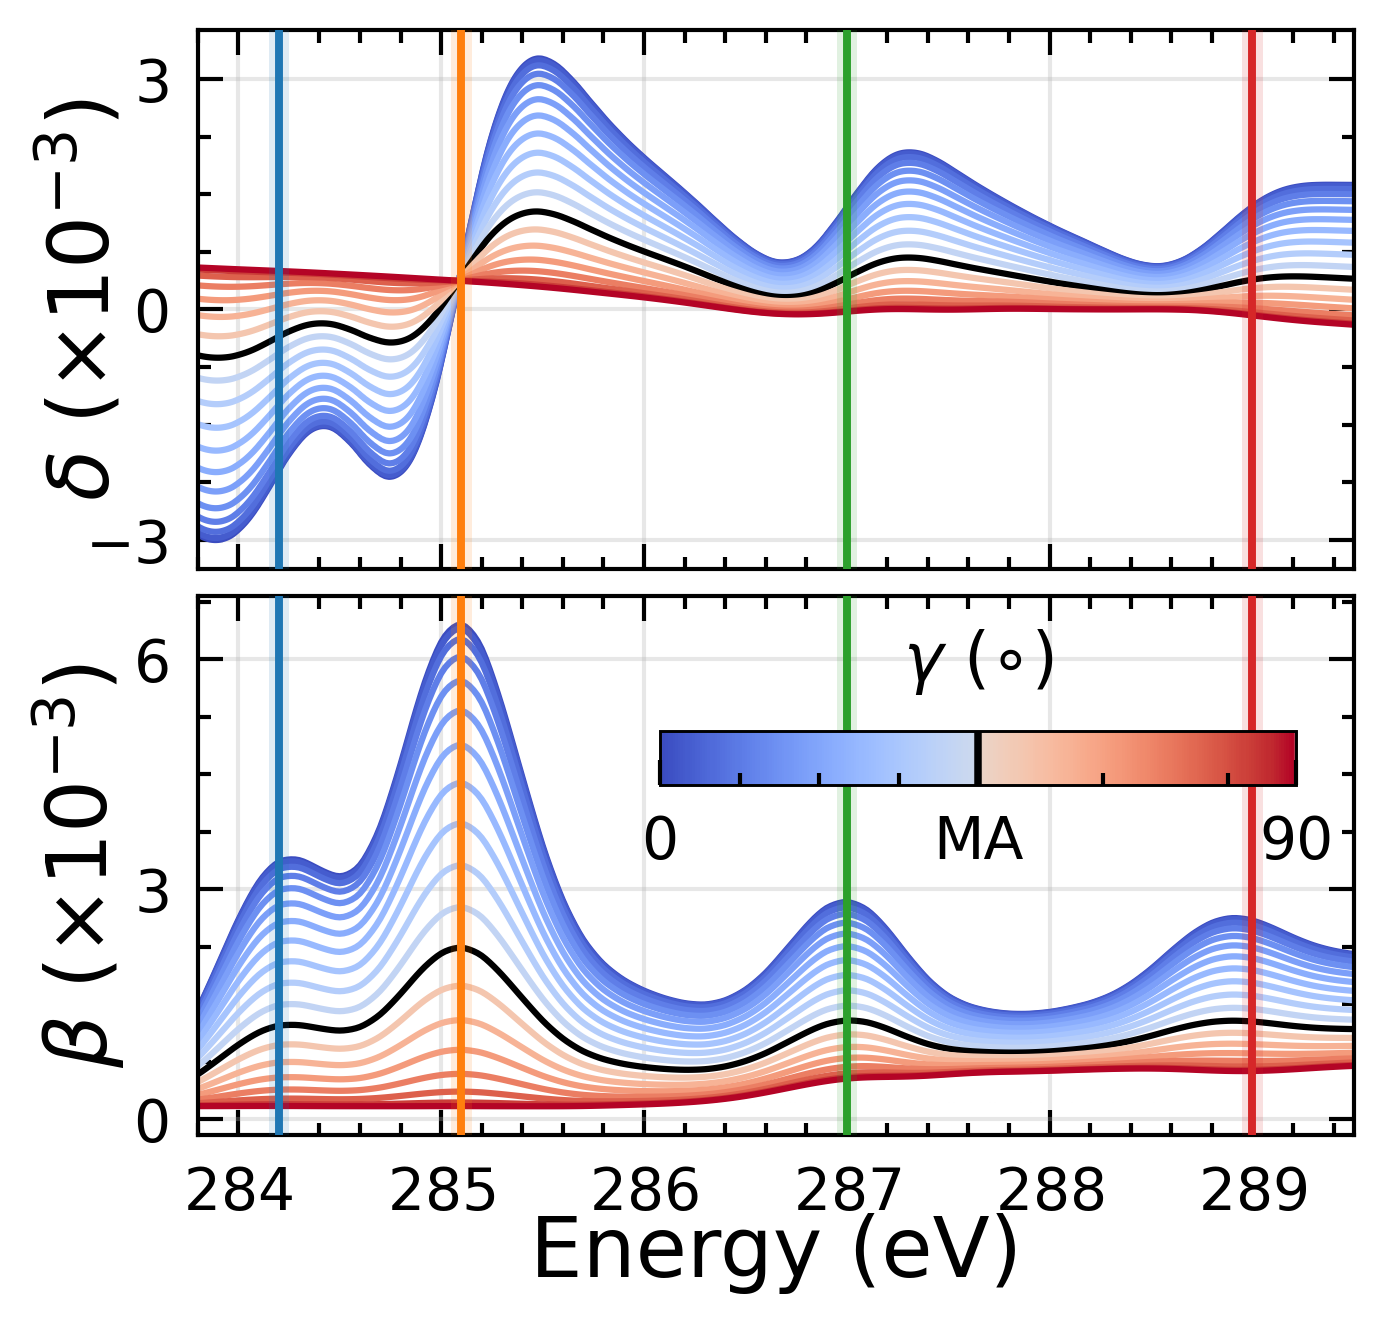

In [168]:
"""
Minimal lab-frame delta_zz / beta_zz vs energy, colored by molecular orientation.

Square panel (2.0 in). Resonant probe energies are vertical p-pol tab20 v-lines
on both traces; a thin gamma legend sits inside the delta panel, diverging at 55 deg
via ``coolwarm`` with black at 55 deg, marked on the inset colorbar.
"""

from __future__ import annotations

from collections.abc import Sequence
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from matplotlib import gridspec
from matplotlib import patheffects as pe
from matplotlib.collections import LineCollection
from matplotlib.colorbar import ColorbarBase
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm

WID = 2.35
HEIGHT = 2.22
E_LO, E_HI = 283.8, 290.0
RESONANT_EDGE = 283.7
MAGIC_ANGLE_DEG = 55.0
_SCALE_1E3 = 1.0e3
_LABEL_HALO = [pe.withStroke(linewidth=1.8, foreground="white")]


def magic_angle_cmap() -> LinearSegmentedColormap:
    """``coolwarm`` diverging map with black at the 55 deg midpoint."""
    base = plt.get_cmap("coolwarm")
    n = 126
    stops = (
        [*base(np.linspace(0.0, 0.44, n))]
        + [(0.0, 0.0, 0.0, 1.0), (0.0, 0.0, 0.0, 1.0)]
        + [*base(np.linspace(0.56, 1.0, n))]
    )
    return LinearSegmentedColormap.from_list("coolwarm_black55", stops, N=256)


def _rotate_zz(xx: np.ndarray, zz: np.ndarray, gamma: np.ndarray) -> np.ndarray:
    """Out-of-plane lab component: xx*sin^2(gamma) + zz*cos^2(gamma)."""
    cs = np.cos(gamma) ** 2
    return xx * (1.0 - cs) + zz * cs


def waterfall_p_color(energy: float, energies: Sequence[float]):
    """p-pol tab20 swatch for one resonant waterfall row."""
    cmap = plt.colormaps.get_cmap("tab10")
    ordered = sorted(float(e) for e in energies)
    idx = ordered.index(float(energy))
    return f"C{idx}"


def optical_zz_orientation_grid(
    ooc_df,
    component: str,
    *,
    e_lo: float = E_LO,
    e_hi: float = E_HI,
    gamma_deg: np.ndarray | None = None,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Build ``beta_zz(E, gamma)`` or ``delta_zz(E, gamma)`` on the DFT OOC grid.

    Parameters
    ----------
    component : {"beta", "delta"}
        Select imaginary (``n_ixx``, ``n_izz``) or real (``n_xx``, ``n_zz``) tensor.
    """
    if component not in {"beta", "delta"}:
        raise ValueError(f"component must be 'beta' or 'delta', got {component!r}")
    if gamma_deg is None:
        gamma_deg = np.arange(0.0, 90.0 + 1.0, 5.0)
    win = ooc_df[(ooc_df["energy"] >= e_lo) & (ooc_df["energy"] <= e_hi)].copy()
    if win.empty:
        raise ValueError(f"No OOC rows in [{e_lo}, {e_hi}] eV.")
    xx_col, zz_col = ("n_ixx", "n_izz") if component == "beta" else ("n_xx", "n_zz")
    energy = win["energy"].to_numpy(dtype=float)
    xx = win[xx_col].to_numpy(dtype=float)[:, None]
    zz = win[zz_col].to_numpy(dtype=float)[:, None]
    gamma = np.deg2rad(gamma_deg)[None, :]
    trace = _rotate_zz(xx, zz, gamma)
    return energy, gamma_deg, trace


def _style_trace_axis(ax, *, ylabel: str, show_xlabels: bool) -> None:
    """Manuscript-style boxed axes with inward ticks on all sides."""
    from matplotlib.ticker import MaxNLocator
    ax.set_ylabel(ylabel, labelpad=-5)
    ax.yaxis.set_major_locator(MaxNLocator(integer=True, nbins=3))
    # set tick labels to be font size 7
    ax.tick_params(axis="both", which="both", direction="in", labelsize=7)
    # ax.tick_params(
    #     axis="both",
    #     which="both",
    #     direction="in",
    #     top=True,
    #     right=True,
    #     labelsize=6.5,
    #     length=2.5,
    #     width=0.6,
    # )
    # ax.tick_params(axis="both", which="minor", length=1.5, width=0.5)
    # for spine in ax.spines.values():
    #     spine.set_visible(True)
    #     spine.set_linewidth(0.6)
    # ax.grid(False)
    # ax.minorticks_on()
    if show_xlabels:
        ax.set_xlabel("Energy (eV)", labelpad=-1)
    else:
        plt.setp(ax.get_xticklabels(), visible=False)



def _add_resonant_vlines(ax, resonant: Sequence[float], *, pillar_w: float = 0.10) -> None:
    """Colored vertical guides at panel-(d) probe energies."""
    cmap = plt.colormaps.get_cmap("tab10")
    for i, e_p in enumerate(resonant):
        col = cmap(i)
        ax.axvspan(
            e_p - pillar_w / 2,
            e_p + pillar_w / 2,
            color=col,
            alpha=0.14,
            zorder=5,
            lw=0,
        )
        ax.axvline(e_p, color=col, lw=0.95, alpha=1.0, zorder=5)


def _add_orientation_lines(ax, energy, gamma_deg, values, *, cmap, norm) -> None:
    segments = [np.column_stack([energy, values[:, j]]) for j in range(len(gamma_deg))]
    colors = [cmap(norm(g)) for g in gamma_deg]
    ax.add_collection(
        LineCollection(segments, colors=colors, linewidths=0.75, capstyle="round", zorder=2)
    )


def _draw_inset_gamma_legend(ax, *, cmap, norm) -> None:
    """Thin horizontal gamma legend embedded in the delta panel."""
    cax = ax.inset_axes([0.4, 0.65, 0.55, 0.1])
    cax.set_facecolor((1.0, 1.0, 1.0, 0.82))
    cax.patch.set_alpha(0.82)
    cb = ColorbarBase(
        cax,
        cmap=cmap,
        norm=norm,
        orientation="horizontal",
        ticks=[0, MAGIC_ANGLE_DEG, 90],
    )
    cb.set_ticklabels(["0", "MA", "90"], fontsize=7)
    cax.axvline(MAGIC_ANGLE_DEG, color="k", lw=0.9, zorder=10)
    cax.set_title(r"$\gamma$ ($\circ$)", fontsize=8)
    # cax.tick_params(labelsize=5, length=1.5, width=0.35, direction="out", pad=0.5)
    cax.xaxis.set_ticks_position("bottom")
    cax.xaxis.set_label_position("bottom")
    for spine in cax.spines.values():
        spine.set_linewidth(0.35)
    cax.set_zorder(6)


def plot_optical_orientation_panel(
    ooc_df,
    resonant_energies,
    *,
    save_path: Path | str | None = "fig2_beta_orientation.png",
    e_lo: float = E_LO,
    e_hi: float = E_HI,
    fig_width: float = WID,
    fig_height: float = HEIGHT,
):
    """
    Plot delta_zz (top) and beta_zz (bottom) vs energy with gamma-colored traces.

    Traces use ``coolwarm`` with black at ``MAGIC_ANGLE_DEG`` (55 deg).
    Y values are plotted in units of 10^-3 with the scale noted on the axis label.

    Returns
    -------
    Figure
    """
    resonant = sorted(float(e) for e in resonant_energies if e_lo <= float(e) <= e_hi)
    energy, gamma_deg, beta_zz = optical_zz_orientation_grid(ooc_df, "beta", e_lo=e_lo, e_hi=e_hi)
    _, _, delta_zz = optical_zz_orientation_grid(
        ooc_df, "delta", e_lo=e_lo, e_hi=e_hi, gamma_deg=gamma_deg
    )

    norm = TwoSlopeNorm(vmin=0.0, vcenter=MAGIC_ANGLE_DEG, vmax=90.0)
    cmap = magic_angle_cmap()

    fig = plt.figure(figsize=(fig_width, fig_height), dpi=600)
    gs = gridspec.GridSpec(
        2,
        1,
        figure=fig,
        height_ratios=[1.0, 1.0],
        hspace=0.05,
        left=0.16,
        right=0.98,
        top=0.96,
        bottom=0.13,
    )
    ax_d = fig.add_subplot(gs[0])
    ax_b = fig.add_subplot(gs[1], sharex=ax_d)

    for ax, values, ylabel, show_xlabels in (
        (ax_d, delta_zz, r"$\delta$ ($\times 10^{-3}$)", False),
        (ax_b, beta_zz, r"$\beta$ ($\times 10^{-3}$)", True),
    ):
        scaled = values * _SCALE_1E3
        y_lo, y_hi = float(scaled.min()), float(scaled.max())
        pad = 0.06 * (y_hi - y_lo if y_hi > y_lo else abs(y_hi) + 1.0)
        ax.set_ylim(y_lo - pad, y_hi + pad)
        ax.set_xlim(energy.min(), 289.5)
        _add_resonant_vlines(ax, resonant)
        _add_orientation_lines(ax, energy, gamma_deg, scaled, cmap=cmap, norm=norm)
        _style_trace_axis(ax, ylabel=ylabel, show_xlabels=show_xlabels)

    _draw_inset_gamma_legend(ax_b, cmap=cmap, norm=norm)

    # for i, e_p in enumerate(resonant):
    #     col = f"C{i}"
    #     ax_d.annotate(
    #         f"{e_p:g}",
    #         xy=(e_p, 1.0),
    #         xycoords=("data", "axes fraction"),
    #         xytext=(0, 2),
    #         textcoords="offset points",
    #         ha="center",
    #         va="bottom",
    #         fontsize=8,
    #         color=col,
    #         path_effects=_LABEL_HALO,
    #         zorder=4,
    #         # bold
    #         weight="bold",
    #     )
    fig.align_labels()

    if save_path is not None:
        path = Path(save_path)
        fig.savefig(path, dpi=600, bbox_inches="tight", transparent=True)
        fig.savefig(path.with_suffix(".pdf"), dpi=600, bbox_inches="tight", transparent=True)

    return fig

SAVE_NAME="FIG2.3.png"

_resonant_energies = [e for e in ens if e > RESONANT_EDGE]
fig_beta_orientation = plot_optical_orientation_panel(ooc, _resonant_energies, save_path=SAVE_NAME)
